# Libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import pickle
import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d
import pandas as pd
import ast
import time
from collections import defaultdict
import time



# def nested_dict(n, type):
#     if n == 1:
#         return defaultdict(type)
#     else:
#         return defaultdict(lambda: nested_dict(n-1, type))
    
# dataf = nested_dict(5, list)

from IPython.display import Audio

# Define the audio tone
duration = 1.2  # in seconds
freq = 320  # in Hz
sample_rate = 4410  # in samples per second
t = np.linspace(0, duration, int(duration * sample_rate), False)
audio_data = np.sin(2 * np.pi * freq * t)
# Display the audio tone
# Audio(audio_data, rate=sample_rate, autoplay=True)

# Bias as a function of mass

In [2]:
from colossus.lss import peaks
from colossus.lss import bias
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18');
M = 1.e14
z = 0.0
# nu = peaks.peakHeight(M, z)
# b = bias.haloBiasFromNu(nu, model = 'sheth01')
bias = bias.haloBias(M, model = 'tinker10', z = z, mdef = '200m')
print(bias)

2.054262883708949


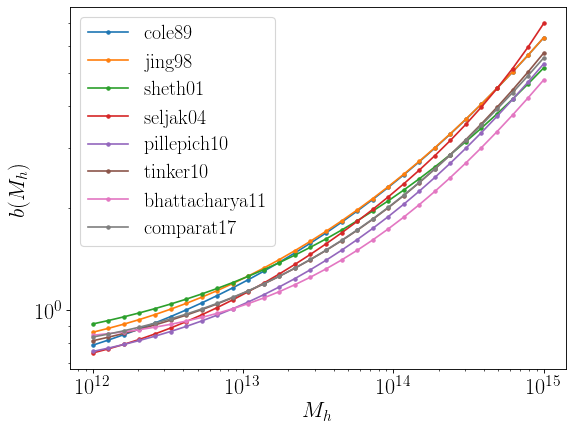

In [4]:
#########
c=20
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(8, 6), dpi=80)

#########
from colossus.lss import peaks
from colossus.lss import bias
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18');

# Define the mass range and number of points
M_min = 1.e12
M_max = 1.e15
num_points = 30

# Generate a logarithmically spaced array of masses
M_array = np.logspace(np.log10(M_min), np.log10(M_max), num_points)

# Define other necessary variables
z = 0.0
mdef = '200m'

# Instantiate the halo model and bias model
#["sheth01","tinker10","comparat17"]:
for model in bias.models:
# for model in ["sheth01","tinker10","pillepich10"]:
    bias_model = bias.haloBias(M_array, model = model, z = z, mdef = mdef)
    plt.loglog(M_array, bias_model,".-",label=model)

plt.ylabel(r"$b(M_h)$")
plt.xlabel(r"$M_h$")
plt.legend(fontsize=18)

# Tests

In [5]:
import seaborn as sns
do_the_analysis = "no"
plot_position ="no"
plot_velocity ="no"
plot_bulk_velocity ="no"
plot_mass ="no"





if do_the_analysis =="yes":
    n_grid = 21
    boxsize = 2048
    sim_spec= "L_2048_Ngrid_4096"
    sim="0meV"
    halos_catalogue = np.loadtxt("./../../simulations/Neutrino_runs_JulianAdamek/nu"+sim+"_2048box_4096_snap004_halos_parents.dat");
    print("Halo catalogue has been read!")
    with open('../Runs/'+sim_spec+'/'+sim+'/output/data_ngrid_'+str(n_grid)+'_sim_'+sim_spec+'_'+sim+'_snap_4.pickle','rb') as handle:
        n_grid_halos = pickle.load(handle);
    print("The file has been loaded!")
    pp_file = np.load('./Analysis_large_sims//'+sim+'/ngrid_'+str(n_grid)+'.npy');
    print("The post-processing file has been loaded!")

# We load the halo catalogue
    # halos_catalogue = np.loadtxt("./../../simulations/L_1024_Ngrid_512/0.0ev/output/halos/out_2.list")
    # positions: columns = 8, 9, 10
    # velocities: columns = 11, 12 , 13
    # Mass (M200b): column = 20

    # Halos in a N_grid
    ## We check that for a give halo in original halo catalogue its velocity and position agrees with the post processed catalogue!
    # We choose halo number
    h_num = 1021 # halo number
    pos_halo = halos_catalogue[h_num,8:11]
    vel_halo = halos_catalogue[h_num,11:14]
    print("halo number " + str(h_num)+ " with mass "+"{:.2e}".format(halos_catalogue[h_num,20])+" is chosen for the check!")

    ### Finding the halo in sub-box
    desired_position =pos_halo
    for j in range(n_grid_halos['sub_box_index'].shape[0]):
        for i in range(np.shape(n_grid_halos['halo_pos'][j])[0]):
            if np.allclose(n_grid_halos['halo_pos'][j][i], desired_position):
                print("The sub-box and number: ", i, j)
                i_found = i
                cell_found = j
                break
        else:
            continue
        break

    ### Finding the halo in the post processed file
    desired_vel_m_v_bulk =vel_halo-n_grid_halos['bulk_vel'][cell_found];

    for i in range (np.shape(pp_file)[0]):
        if np.allclose(pp_file[i,0:3], desired_vel_m_v_bulk):
                print("The number of index in the post processing:", i)
                index_halo = i
                break
        else:
            continue
        break


    print("\n Mass of halo in original halo finder: ", "{:.2e}".format(halos_catalogue[h_num,20]))
    print("Mass of halo in the file: ", "{:.2e}".format(n_grid_halos['halo_mass'][cell_found][i_found]))
    print("In our post processing analysis the mass of halo is ","{:.2e}".format(pp_file[index_halo,6]))

    print("\n Velocity of the halo in original halo finder: ", halos_catalogue[h_num,11:14])
    print("Velocity of the halo  in the file: ", n_grid_halos['halo_vel'][cell_found][i_found])

    print("\n Based on the position, boxsize "+str(boxsize)+" and n_grid "+str(n_grid)+" the halo is expected to be in sub-box: ", np.floor(pos_halo*n_grid/boxsize) )
    print("In our analysis the halo is in the sub-box", n_grid_halos['sub_box_index'][cell_found])

    print("\n For this halo the v-v_b is ", n_grid_halos['halo_vel'][cell_found][i_found] -   n_grid_halos['bulk_vel'][cell_found])
    print("In our post processing analysis the reported v-v_b is ", pp_file[index_halo,:3])


    print("\n  In our post processing analysis the v_bulk of halo is ", pp_file[index_halo,3:6])
    print("In our analysis the v_bulk of halo is", n_grid_halos['bulk_vel'][cell_found])

# pp_file

if plot_position =="yes":
    c=26
    plt.rc('text', usetex=True)
    font = {'family' : 'normal',
            'weight' : 'bold',
            'size'   : c}
    matplotlib.rc('font', **font)
    figure(figsize=(14, 11), dpi=80)
    sns.kdeplot(halos_catalogue[::1,8] , bw_adjust=1, alpha=0.7, label="x")
    sns.kdeplot(halos_catalogue[::1,9] , bw_adjust=1, alpha=0.7, label="y")
    sns.kdeplot(halos_catalogue[::1,10] , bw_adjust=1, alpha=0.7, label="z")
    plt.xlabel("position")
    plt.legend()
    
if plot_velocity =="yes":
    c=26
    plt.rc('text', usetex=True)
    font = {'family' : 'normal',
            'weight' : 'bold',
            'size'   : c}
    matplotlib.rc('font', **font)
    figure(figsize=(14, 11), dpi=80)
    sns.kdeplot(halos_catalogue[::1,11] , bw_adjust=1, alpha=0.7, label=r"$v_x$")
    sns.kdeplot(halos_catalogue[::1,12] , bw_adjust=1, alpha=0.7, label=r"$v_y$")
    sns.kdeplot(halos_catalogue[::1,13] , bw_adjust=1, alpha=0.7, label=r"$v_z$")
    plt.xlabel("velocity")

    plt.legend()
    
    c=26
    plt.rc('text', usetex=True)
    font = {'family' : 'normal',
            'weight' : 'bold',
            'size'   : c}
    matplotlib.rc('font', **font)
    figure(figsize=(14, 11), dpi=80)
    sns.kdeplot(np.sqrt(halos_catalogue[::1,11]**2 + halos_catalogue[::1,12]**2 + halos_catalogue[::1,13]**2) , bw_adjust=1, alpha=0.7, label=r"$\sqrt{\vec v . \vec v}$")
    # plt.xscale('symlog')
    plt.xlabel("velocity[km/s]")
    # plt.xlim(-1000,1000)
    plt.legend()
    
if plot_bulk_velocity=="yes":
    figure(figsize=(14, 11), dpi=80)
    sns.kdeplot(data = np.vstack(n_grid_halos['bulk_vel'][:])[:,0] , bw_adjust=1, alpha=0.7, label=r"$v^{(bulk)}_x$")
    sns.kdeplot(data = np.vstack(n_grid_halos['bulk_vel'][:])[:,1] , bw_adjust=1, alpha=0.7, label=r"$v^{(bulk)}_y$")
    sns.kdeplot(data = np.vstack(n_grid_halos['bulk_vel'][:])[:,2] , bw_adjust=1, alpha=0.7, label=r"$v^{(bulk)}_z$")
    plt.xlabel("$v^{(bulk)}$")

    plt.legend()
    
if plot_mass =="yes":
    figure(figsize=(14, 11), dpi=80)
    # sns.kdeplot(halos_catalogue[::1,20], bw_adjust=1, alpha=0.7)
    plt.hist(np.log10(halos_catalogue[::1,20]))

    # plt.gca().set_xscale('log')
    plt.xlabel(r"$\log(M_{\rm 200b})$")
    plt.legend()
    
# Audio(audio_data, rate=sample_rate, autoplay=True)
     

# Plot

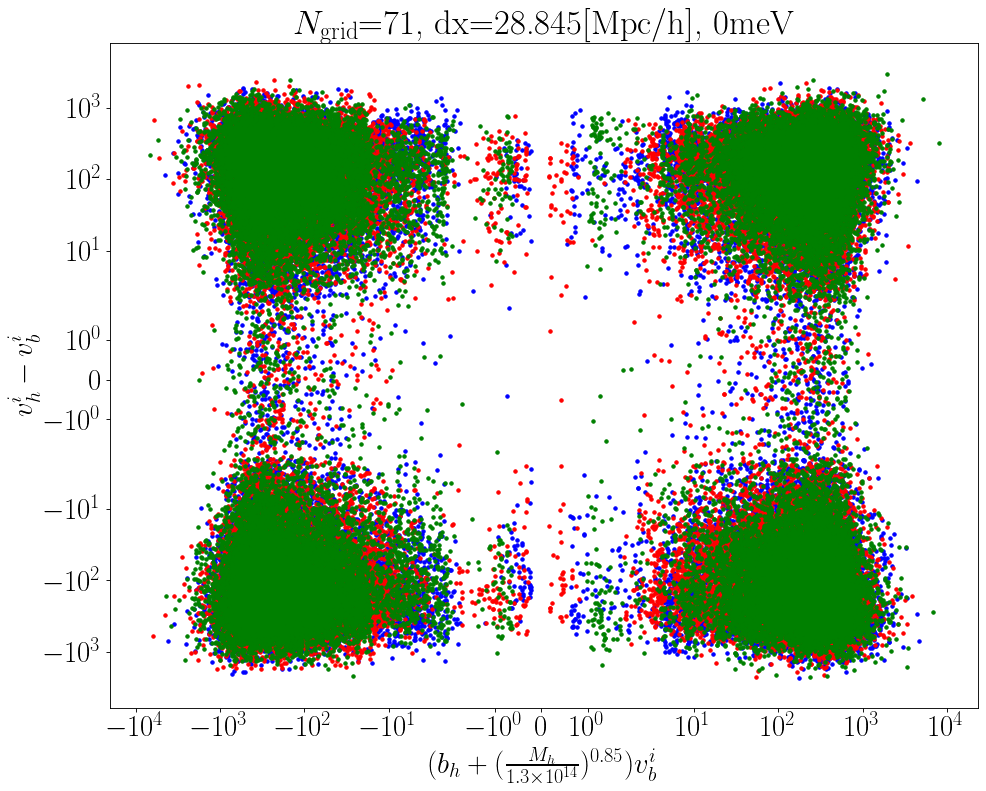

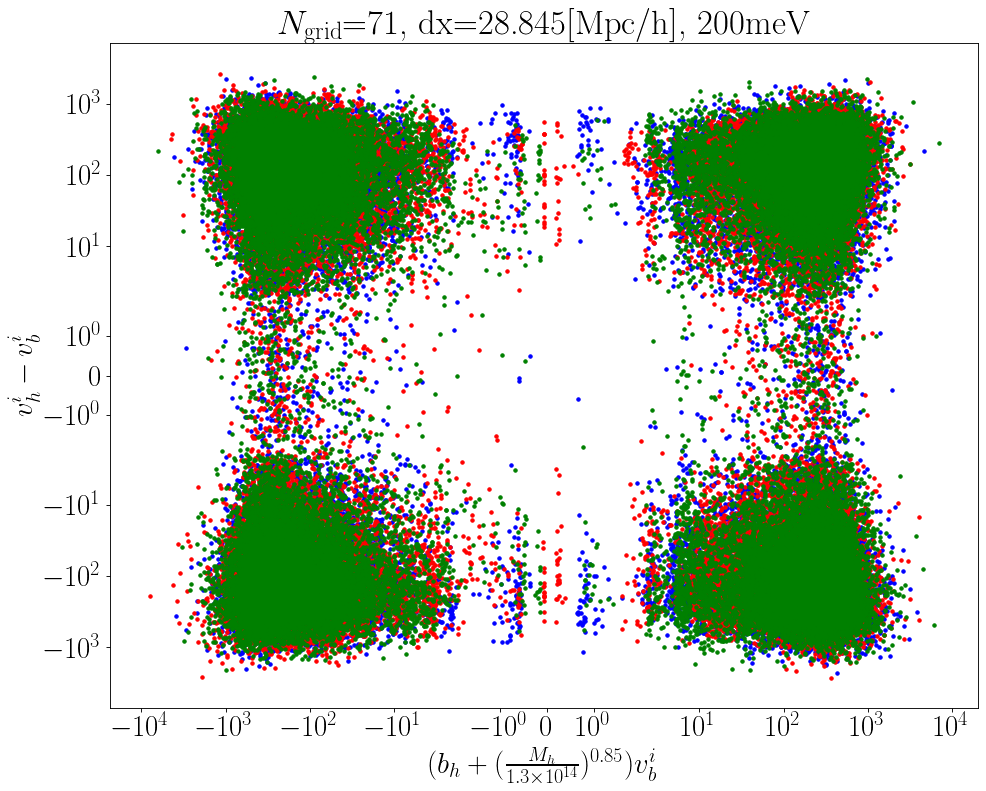

In [8]:

## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'

sims = ["0meV", "200meV", "300meV", "60meV"]
for sim in sims[:2]:
    
    ###FIG###
    c=26
    plt.rc('text', usetex=True)
    font = {'family' : 'normal',
            'weight' : 'bold',
            'size'   : c}
    matplotlib.rc('font', **font)
    figure(figsize=(14, 11), dpi=80)
    #########
    for n_grid in [71]:
        nm=60000
        address_saved = "./Analysis_large_sims///"+sim;
        a = np.load(address_saved+"/ngrid_"+str(n_grid)+".npy", allow_pickle=True)
        masses = a[:nm,6];
        #######
        v_bulk_x = a[:nm,3];
        v_bulk_y = a[:nm,4];
        v_bulk_z = a[:nm,5];
        biases = bias.haloBias(masses, model = 'sheth01', z = 0.0, mdef = '200m')
        x1 = (biases + (masses/(1.3*1.e14))**(0.85))*v_bulk_x;
        x2 = (biases + (masses/(1.3*1.e14))**(0.85))*v_bulk_y;
        x3 = (biases + (masses/(1.3*1.e14))**(0.85))*v_bulk_z; 

        y1 = a[:nm,0]; # vi_x - v_b_x
        y2 = a[:nm,1]; # vi_x - v_b_x
        y3 = a[:nm,2]; # vi_x - v_b_x
        # print(y1, y2, y3)
        plt.plot(x1,y1,"b.")
        plt.plot(x2,y2,"r.")
        plt.plot(x3,y3,"g.")

        # plt.plot(x1,y1,"b.")
        # plt.plot(x2,y2,"b.")
        # plt.plot(x3,y3,"b.")
        plt.yscale('symlog')
        plt.xscale('symlog')

        plt.xlabel(r"$(b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$")
        plt.ylabel(r"$v_h^i - v_b^i$")
        plt.title(r"$N_{\rm grid}$="+str(n_grid)+", dx="+str(np.round(2048/n_grid,3))+"[Mpc/h]"+", "+sim)

        # bias_model = bias.haloBias(M_array, model = model, z = z, mdef = mdef)
        

# Computing $\frac{\langle(\vec v_h - \vec v_b).(b_h + (\frac{M_h}{1.3 \times 10^{14}})^{0.85})\vec v_b \rangle}{\langle v_b.v_b\rangle}$ where $\vec v_b$ is the bulk velocity and $\vec v_h$ is the halo velocity.

In [7]:
do_the_analysis =True

Mass_cuts = [1.e12, 5.e12, 1.e13, 2.e13, 3.e13, 4.e13, 5.e13, 6.e13, 7.e13, 8.e13, 9.e13, 1.e14, 2.e14, 5.e14,7.e14, 1.e15];
ngrid_min = 1
ngrid_max = 160 # 160
ngrid_step = 2
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
sims = ["0meV", "200meV", "300meV", "60meV"]

if do_the_analysis == True:
    for Mass_cut in Mass_cuts:
        df = pd.DataFrame()
        print("The analysis is being done for Mass_cut:"+f"{Mass_cut:.2e}")
        ## Halo model:
        model = 'sheth01'
        z = 0.0
        mdef = '200m'
        for sim in sims:
            for n_grid in ngrid_list:
                address_save = "./Analysis_sims_L_2048_Ngrid_4096//"+sim;
                file_path = address_save+"/ngrid_"+str(n_grid)+".npy"
                if os.path.exists(file_path):
                    a = np.load(file_path, allow_pickle=True)
                    ######
                    mass_conditions = (a[:,6]>=Mass_cut)
                    a = a[mass_conditions]
                    masses = a[:,6];                    
                    #######
                    v_bulk_x = a[:,3];
                    v_bulk_y = a[:,4];
                    v_bulk_z = a[:,5];
                    biases = bias.haloBias(masses, model = 'sheth01', z = 0.0, mdef = '200m')
                    x1 = (biases + (masses/(1.3*1.e14))**(0.85))*v_bulk_x;
                    x2 = (biases + (masses/(1.3*1.e14))**(0.85))*v_bulk_y;
                    x3 = (biases + (masses/(1.3*1.e14))**(0.85))*v_bulk_z; 
                    y1 = a[:,0]; # vi_x - v_b_x
                    y2 = a[:,1]; # vi_x - v_b_x
                    y3 = a[:,2]; # vi_x - v_b_x

                    cor_x = np.average(x1*y1)
                    cor_y = np.average(x2*y2)
                    cor_z = np.average(x3*y3)
                    cor_all_vel = (cor_x + cor_y + cor_z)/(np.average(v_bulk_x*v_bulk_x) + np.average(v_bulk_y*v_bulk_y) + np.average(v_bulk_z*v_bulk_z));
                    cor_all = (cor_x + cor_y + cor_z)/(np.average(x1*x1) + np.average(x2*x2) + np.average(x3*x3));

                    # create a dictionary with the values
                    row_dict = {'sim': sim, 'n_grid': n_grid, 'dx': 1024./n_grid,  'mass_cut': Mass_cut, 'cor_x': cor_x, 'cor_y': cor_y, 'cor_z': cor_z, 'cor_all': cor_all, 'cor_all_vel': cor_all_vel}
                    # append the row to the dataframe
                    df = df.append(row_dict, ignore_index=True)
                else:
                    print(file_path+" doesn't exist!")
        df.to_csv('./correlation_data_L_2048_N_4098/data_L_2048_N_4096_mass_cut_'+f"{Mass_cut:.2e}"'.csv', index=False);

else:
    df=[]
    for Mass_cut in Mass_cuts:
        print("The file "+f"{Mass_cut:.2e}"+" are being read!")
        df.append(pd.read_csv('./correlation_data_L_2048_N_4098/data_L_2048_N_4096_mass_cut_'+f"{Mass_cut:.2e}"'.csv'))




The analysis is being done for Mass_cut:1.00e+12
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_131.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_133.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_135.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_137.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_139.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_141.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_143.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_145.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_147.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_149.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_151.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_153.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_155.npy doesn't exist!
./Analysis_sims_L_2048_Ngrid_4096//0meV/ngrid_157.npy 

KeyboardInterrupt: 

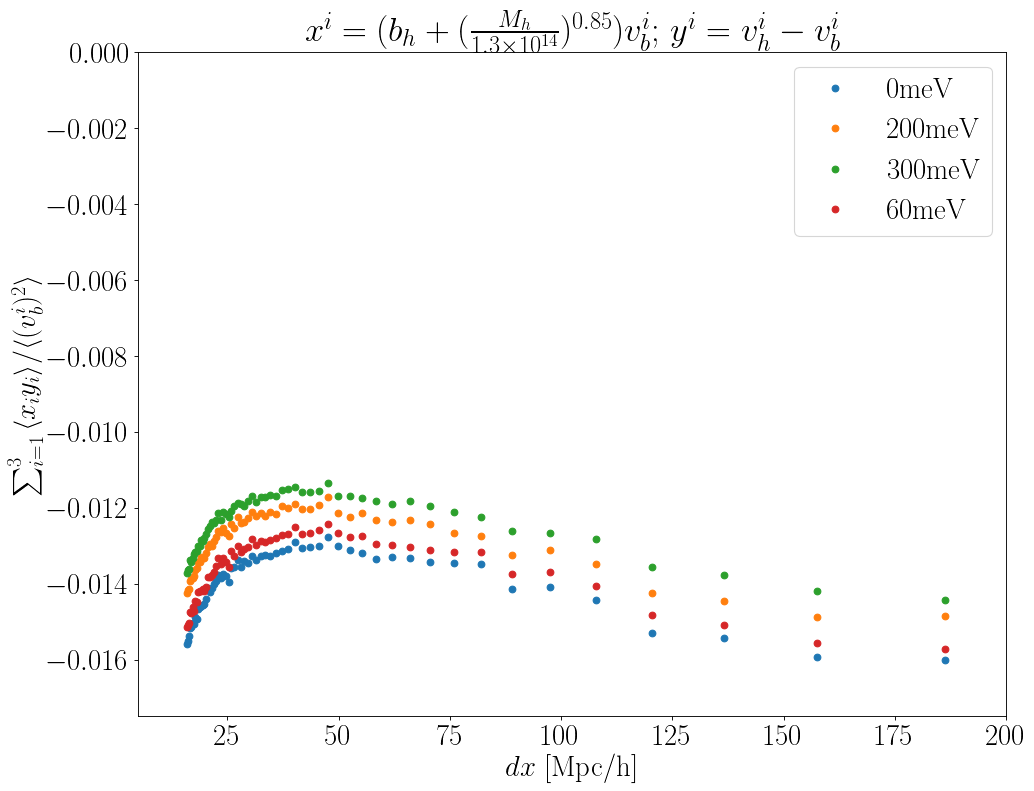

In [13]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0.0ev','0.6ev']:
for sim in sims:


    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_all'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle (v_b^i)^2 \rangle}  $")
    plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
    # plt.yscale('symlog')
    # plt.xscale('log')
    plt.xlim(5,200)
    plt.ylim(-0.0175,0)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

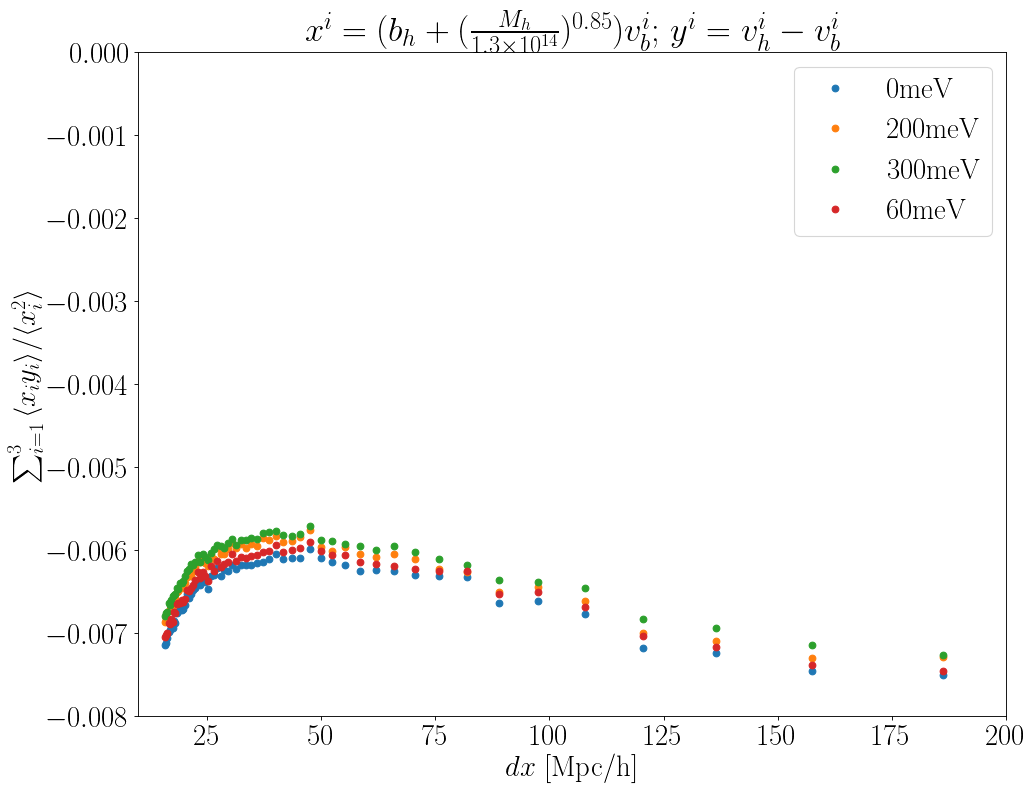

In [14]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
# for sim in ['0.0ev','0.6ev']:
for sim in sims:


    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_all_2'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\sum_{i=1}^3 {\langle x_i y_i \rangle}/{ \langle x_i^2 \rangle}  $")
    plt.title(r"$x^i = (b_h+(\frac{M_h}{1.3 \times 10^{14}})^{0.85}) v_b^i$;  $y^i = v_h^i - v_b^i$")
    # plt.yscale('symlog')
    # plt.xscale('log')
    plt.xlim(10,200)
    plt.ylim(-0.008,0)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

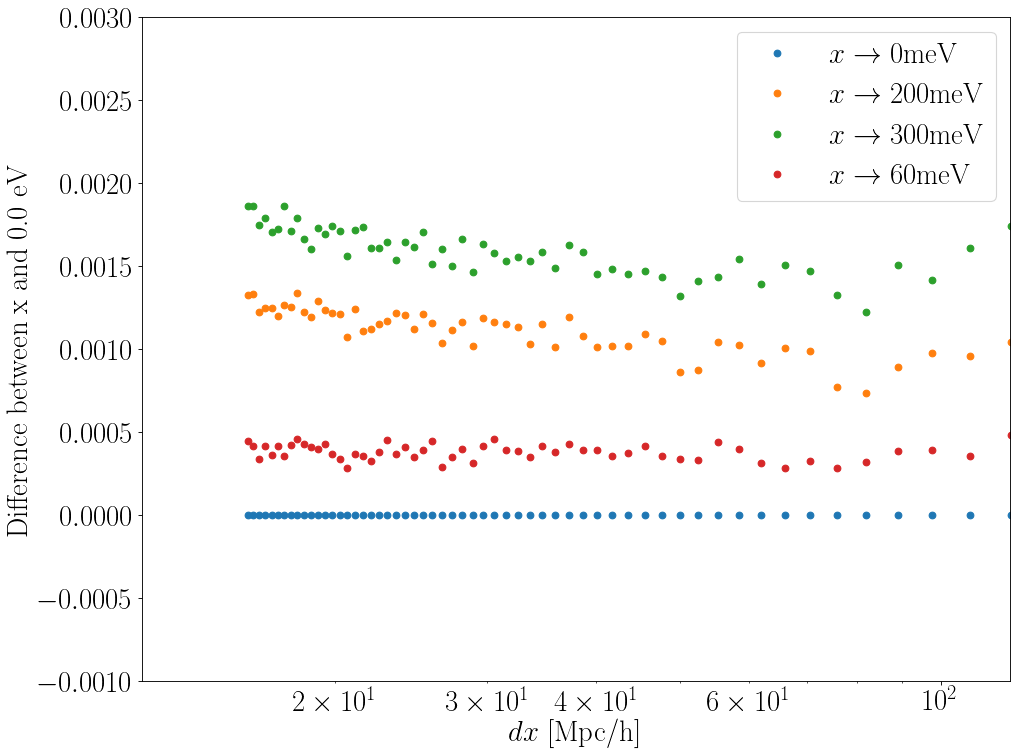

In [17]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
for sim in sims:


    #########
    mask_base = df['sim']=='0meV'
    mask = df['sim']== sim

    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])

    y_b = np.array(df['cor_all'][mask_base]);
    y =np.array( df['cor_all'][mask]);
    
    num=129
    plt.plot(x_b[:num],y[:num]-y_b[:num],"o", label=r"$x \to$ "+sim)
    # plt.plot(x[:74],y[:74],"o")

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"Difference between x and 0.0 eV")
    # plt.title(r"All components of $v_h$ and $v_b$")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(12,120)
    plt.ylim(-1.e-3,3.e-3)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

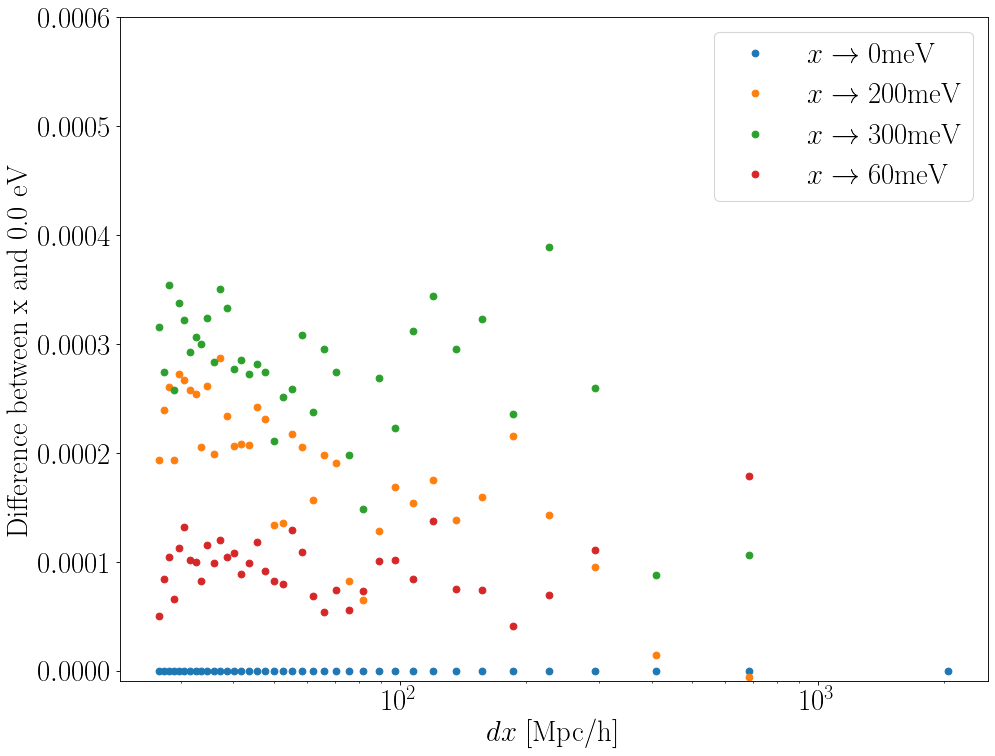

In [18]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
for sim in sims:


    #########
    mask_base = df['sim']=='0meV'
    mask = df['sim']== sim

    x = np.array(df['dx'][mask])
    x_b =np.array(df['dx'][mask_base])

    y_b = np.array(df['cor_all_2'][mask_base]);
    y =np.array( df['cor_all_2'][mask]);
    
    num=39
    plt.plot(x_b[:num],y[:num]-y_b[:num],"o", label=r"$x \to$ "+sim)
    # plt.plot(x[:74],y[:74],"o")

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"Difference between x and 0.0 eV")
    # plt.title(r"All components of $v_h$ and $v_b$")
    # plt.yscale('symlog')
    plt.xscale('log')
    # plt.xlim(12,120)
    plt.ylim(-1.e-5,6.e-4)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

In [55]:
sims

['0meV', '200meV', '300meV', '60meV']

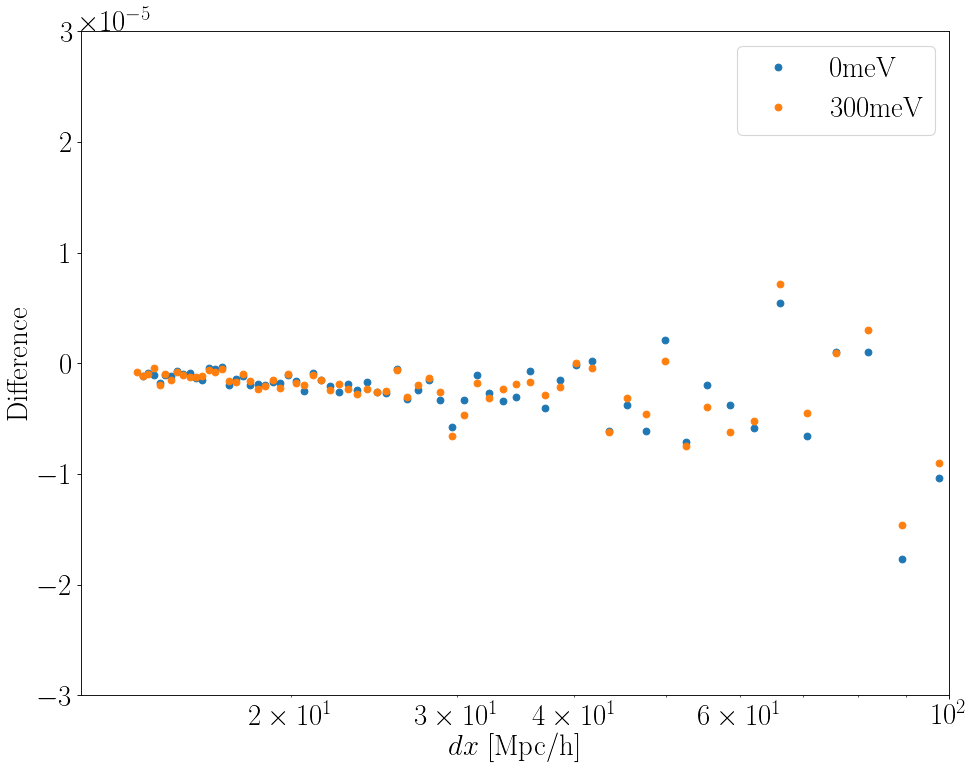

In [18]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
for sim in ['0meV','300meV']:


    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_all'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"Difference")
    # plt.title(r"All components of $v_h$ and $v_b$")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(12,100)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

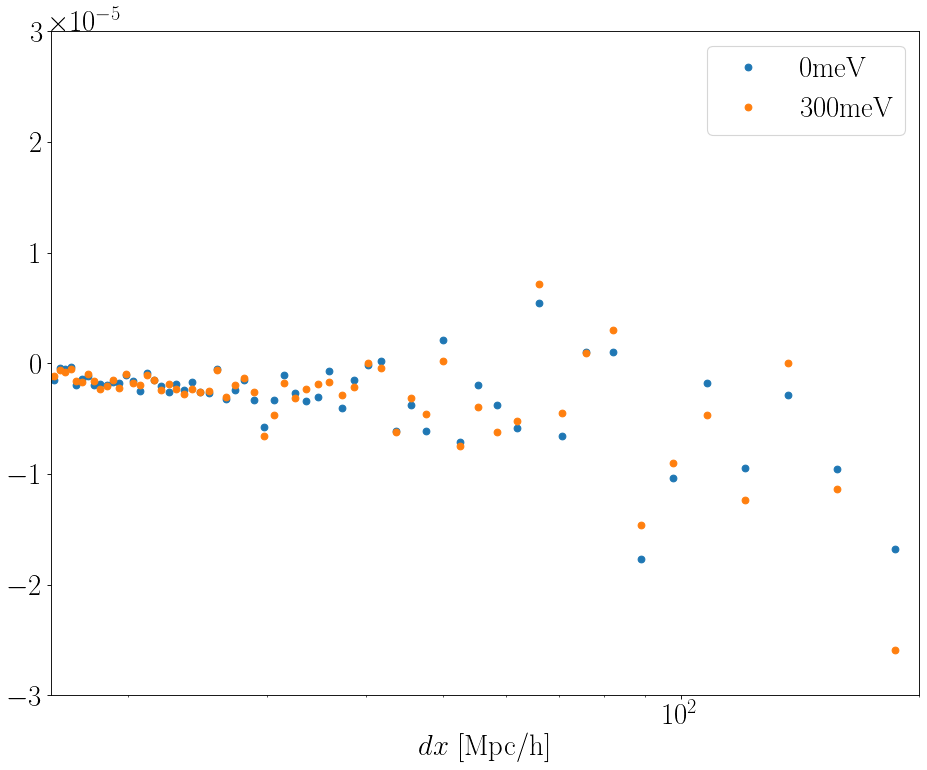

In [10]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
for sim in ['0meV','300meV']:


    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_all'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    # plt.ylabel(r"$\sum_{j=1}^3 \sum_{i=1}^N (v_i^j - v^j_b)(b_i + \frac{M_i}{1.3 \times 10^{14}})^{0.85}v_b^j$")
    # plt.title(r"All components of $v_h$ and $v_b$")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

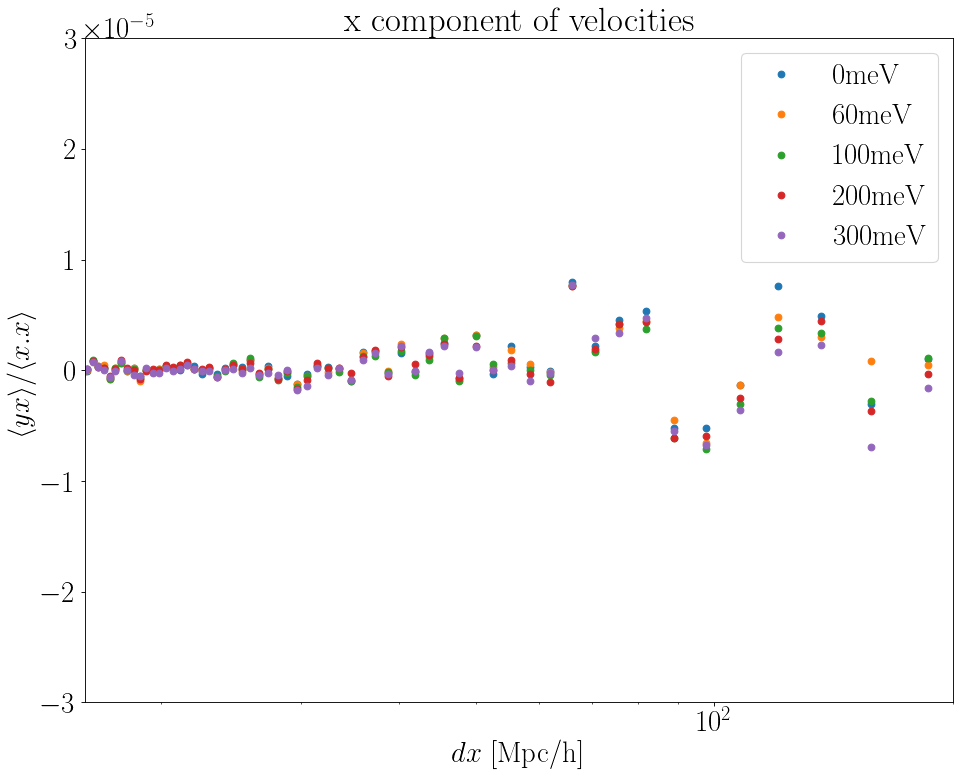

In [71]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    

    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_x'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
    plt.title(r"x component of velocities")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

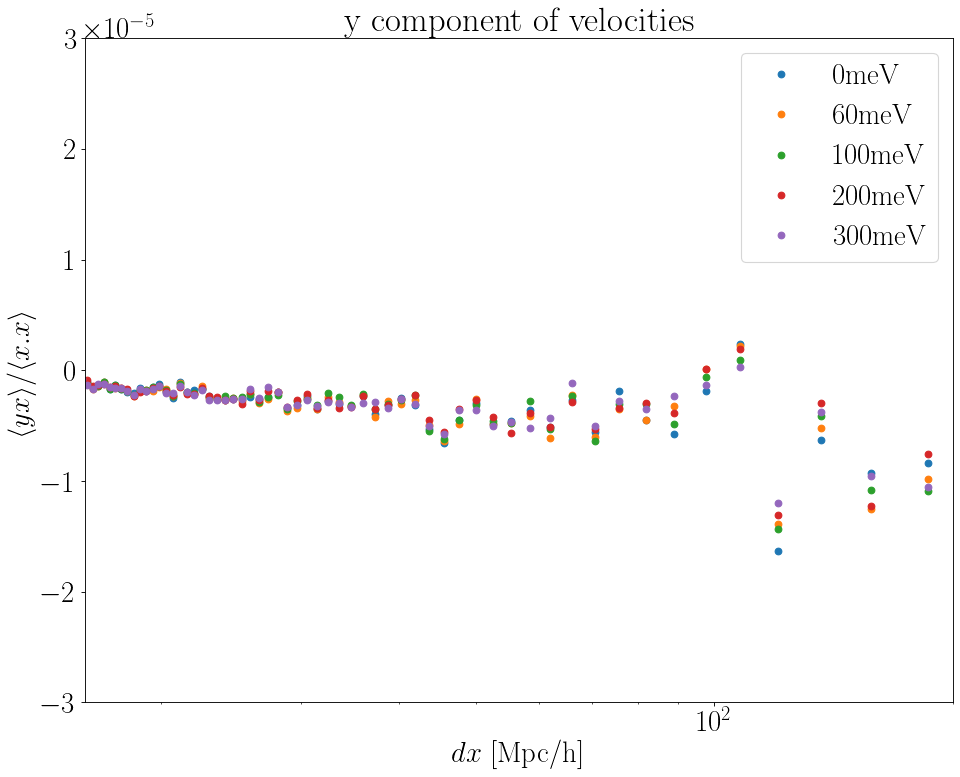

In [75]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    

    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_y'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
    plt.title(r"y component of velocities")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

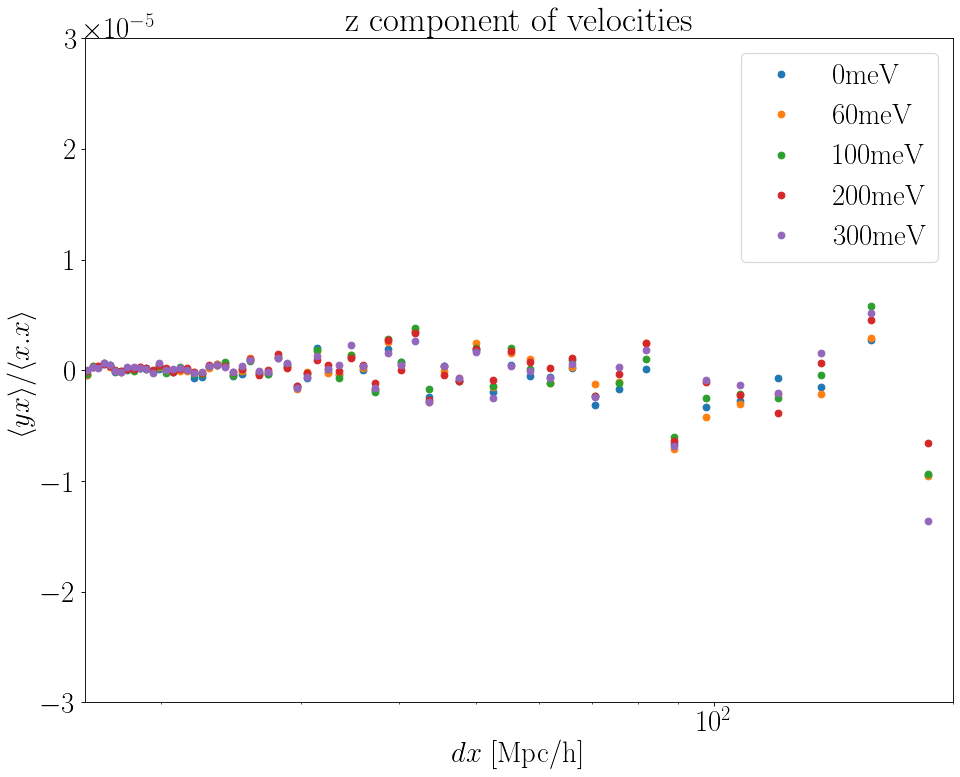

In [76]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    

    #########
    mask = df['sim']==sim
    x = df['dx'][mask]
    y = df['cor_z'][mask];
    plt.plot(x,y,"o",label=sim[:6])

    plt.xlabel(r"$dx$ [Mpc/h]")
    plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
    plt.title(r"z component of velocities")
    # plt.yscale('symlog')
    plt.xscale('log')
    plt.xlim(16,200)
    plt.ylim(-3.e-5,3.e-5)
    plt.legend()
    # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Analyzing the halos and info

In [453]:
sims_size = ['L_2048_N_4096']
sims = ['0meV','60meV','100meV_NH', '200meV','300meV']
ngrid_min = 101
ngrid_max = 103 # 160
ngrid_step = 2
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);

## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###############
for sim in ['0meV','300meV']:
    print(sim);
    file_path = "/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis//parallel_runs/"+sim+"/output/";
    output_data = pd.DataFrame(columns=['v_i-v_b', 'M_h', 'b_h'])

    for n_grid in ngrid_list:
        start_time = time.time()
        if os.path.exists(file_path):
            with open(file_path+'/data_ngrid_'+str(n_grid)+'_sim_L_2048_Ngrid_4096_'+sim+'_snap_4.pickle','rb') as handle:
                df = pickle.load(handle)
            mask = (df['halo_mass'].apply(len) != 0) & (df['halo_vel'].apply(len) != 0)
            df = df[mask].reset_index(drop=True)
            flattened_halo_data = [(v - b, v, m) for sublist in zip(df['halo_vel'], df['halo_mass'], df['bulk_vel']) for v, m, b in zip(sublist[0], sublist[1], [sublist[2]] * len(sublist[0]))]
            # flattened_halo_data = np.array(flattened_halo_data)
            flattened_halo_data = [(np.concatenate((v - b, b, [m])).flatten()) for sublist in zip(df['halo_vel'], df['halo_mass'], df['bulk_vel']) for v, m, b in zip(sublist[0], sublist[1], [sublist[2]] * len(sublist[0]))]
            flattened_halo_data = np.array(flattened_halo_data)
            
            address_save = "./"+sim;
            os.makedirs(address_save, exist_ok=True)
            np.save(address_save+"/ngrid_"+str(n_grid),flattened_halo_data)  

        ### WARNING:
        else:
            print(address_save+"n_grid = "+str(n_grid)+" doesn't exist!")
            
        end_time = time.time()
        print(f"Time taken for {sim} and n_grid={n_grid}: {end_time - start_time} seconds.")


0meV
Time taken for 0meV and n_grid=101: 36.195149421691895 seconds.
300meV
Time taken for 300meV and n_grid=101: 33.15421485900879 seconds.


In [74]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'

# for sim in ['0meV', '60meV', '100meV_NH', '200meV','300meV']:
    
#     ###FIG###
#     c=26
#     plt.rc('text', usetex=True)
#     font = {'family' : 'normal',
#             'weight' : 'bold',
#             'size'   : c}
#     matplotlib.rc('font', **font)
#     figure(figsize=(14, 11), dpi=80)
#     #########
#     mask = df['sim']==sim
#     x = df['dx'][mask]
#     y = df['cor_all'][mask];
#     plt.plot(x,y,"b.")

#     plt.xlabel(r"$dx$ [Mpc/h]")
#     plt.ylabel(r"$\langle yx \rangle/\langle x.x \rangle$")
#     plt.title(r"$\sum_i m_i = $"+sim[:6])
#     # plt.yscale('symlog')
#     plt.xscale('log')
#     plt.xlim(16,200)
#     plt.ylim(-3.e-5,3.e-5)
#     # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )